# Screening real materials with matverse

Materials screening is the problem of narrowing a large candidate list to a
small one you can afford to study properly. The narrowing is cheap and
approximate; the studying is expensive and exact; and almost all the difficulty
lies in keeping track of which is which.

matverse holds a screen in a single [AnnData](https://anndata.readthedocs.io/)
object. Structures, descriptors, computed properties and the record of what
produced them stay together, so a filtered dataset cannot silently point at the
wrong structure and a surrogate energy cannot be quietly averaged with a
first-principles one.

This notebook runs a screen end to end on published structures. It needs no
network, no API key and no downloaded model.

In [1]:
import matverse as mv
import numpy as np
import pandas as pd

mv.pl.set_style()

matverse 0.1.12 — 121 functions


## Loading a dataset

`mv.datasets` ships real structures rather than cells built in code. The
crystallographic data comes from the set [pymatgen](https://pymatgen.org/)
distributes, so nothing is downloaded and the provenance is a package you
already have installed.

We use the olivine and NASICON cathodes:

- **LiFePO₄** — the olivine cathode of [Padhi et al.
  (1997)](https://doi.org/10.1149/1.1837571), the paper that made
  phospho-olivines a cathode class rather than a curiosity
- **NaFePO₄** — the sodium analogue of the same framework, the reason
  sodium-ion work keeps returning to olivines (Moreau et al., *Chem. Mater.*
  2010)
- **Li₃V₂(PO₄)₃** — a NASICON-framework cathode, a different way of building
  open channels out of phosphate polyanions (Yin et al., *J. Am. Chem. Soc.*
  2003)

Three materials is not a screen. It is enough to see what the object does with
them, which is what this page is for.

In [2]:
mv.datasets.available()

{'battery_cathodes': {'structures': ['LiFePO4', 'NaFePO4', 'Li3V2(PO4)3'],
  'description': 'Olivine and NASICON cathode materials. Li and Na analogues of the same framework sit side by side, so an intercalation comparison has something to compare.',
  'use_for': 'mv.neb migration barriers, mv.thermo.hull stability'},
 'solid_electrolytes': {'structures': ['Li10GeP2S12', 'Li2O', 'Li2O2'],
  'description': 'A superionic conductor and two simple lithium oxides. Li10GeP2S12 is the canonical fast-ion conductor and is 58 atoms, so it is also a realistic cost test.',
  'use_for': 'mv.md.conductivity, mv.neb.barrier'},
 'oxides': {'structures': ['SrTiO3', 'TiO2', 'VO2', 'BaNiO3', 'SiO2'],
  'description': 'Perovskite, rutile, and a metal-insulator transition compound. Spans wide-gap insulator to correlated metal.',
  'use_for': 'mv.prop.xrd, mv.thermo.hull, band gap screening'},
 'semiconductors': {'structures': ['Si', 'SiO2', 'TlBiSe2', 'Sn'],
  'description': 'Silicon and its oxide, a topol

In [3]:
md = mv.datasets.load("battery_cathodes")
md

AnnData object with n_obs × n_vars = 3 × 6
    obs: 'name', 'spacegroup', 'dataset', 'source'
    var: 'Z', 'atomic_mass', 'atomic_radius', 'electronegativity', 'group', 'period', 'melting_point', 'boiling_point', 'molar_volume', 'thermal_conductivity', 'electrical_resistivity', 'average_ionic_radius', 'max_oxidation_state', 'min_oxidation_state', 'is_metal', 'is_transition_metal', 'is_alkali', 'is_alkaline', 'is_metalloid', 'is_halogen', 'is_noble_gas', 'is_chalcogen', 'is_lanthanoid', 'is_actinoid', 'is_rare_earth_metal', 'block'
    uns: 'features', 'levels', 'provenance', 'X_is', 'dataset'
    obsm: 'structures'

`X` is the composition matrix and `var` is the periodic table. Neither was asked
for: composition is intrinsic to a material rather than derived from it, so both
are built at construction.

Materials × elements is the same shape as cells × genes — sparse, non-negative,
mostly zero — which is what lets the ordination and enrichment machinery apply
to chemical space without being rewritten.

In [4]:
pd.DataFrame(md.X.toarray(), index=md.obs["name"], columns=md.var_names)

element,Li,O,Na,P,V,Fe
name,,,,,,
LiFePO4,1.0,4.0,0.0,1.0,0.0,1.0
NaFePO4,0.0,4.0,1.0,1.0,0.0,1.0
Li3V2(PO4)3,3.0,12.0,0.0,3.0,2.0,0.0


In [5]:
md.var[["Z", "electronegativity", "period", "is_transition_metal"]]

,Z,electronegativity,period,is_transition_metal
element,,,,
Li,3.0,0.98,2.0,False
O,8.0,3.44,2.0,False
Na,11.0,0.93,3.0,False
P,15.0,2.19,3.0,False
V,23.0,1.63,4.0,True
Fe,26.0,1.83,4.0,True


Because `var` is the periodic table, the natural display of anything
element-indexed is the periodic table itself — here, how many of the three
cathodes each element appears in.

Text(0.5, 1.0, 'the chemistry of this library')

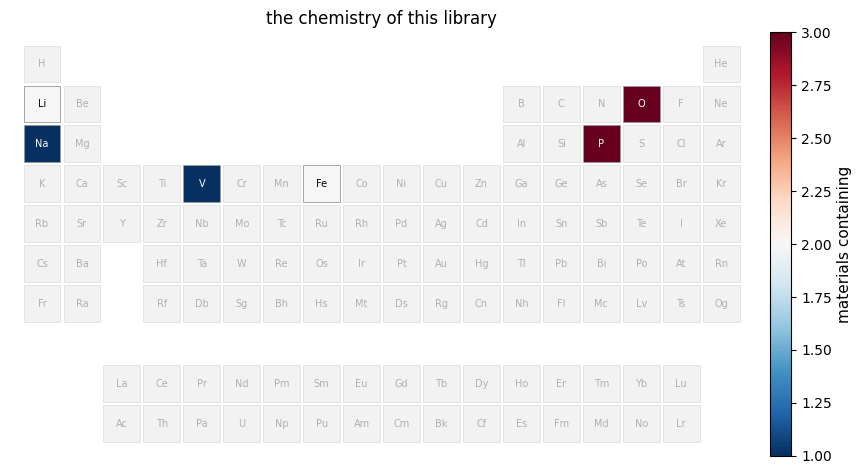

In [6]:
md.var["n_materials"] = (md.X > 0).sum(axis=0).A1

ax = mv.pl.periodic_table(md, color="n_materials", label="materials containing")
ax.set_title("the chemistry of this library")

Counts come from the **reduced** formula, so a supercell and its primitive cell
occupy the same point in chemical space. Cell size lives in `obs['nsites']`.

## Describing and screening the structures

`mv.pp` is the preprocessing namespace, shaped after `scanpy.pp` because the
operations correspond: `qc` is `calculate_qc_metrics`, `filter_materials` is
`filter_cells`.

In [7]:
mv.pp.describe(md)
mv.pp.qc(md)

md.obs[["name", "spacegroup", "formula", "nsites", "density", "is_valid"]]

,name,spacegroup,formula,nsites,density,is_valid
0,LiFePO4,P2_1/c,LiFePO4,28,3.497400,True
1,NaFePO4,Pnma,NaFePO4,28,3.520424,True
2,Li3V2(PO4)3,C2,Li3V2(PO4)3,40,2.875413,True


`spacegroup` is determined from the deposited coordinates, not copied from a
label — which is why LiFePO₄ comes out as P2₁/c rather than the Pnma the olivine
is usually reported in. The framework is the same; the cell in this file is a
lower-symmetry setting of it. `mv.pp.standardize` puts both into a conventional
cell when that matters.

That is the point of shipping published structures rather than a cubic cell
someone typed in: the awkwardness is real and you would meet it anyway.

## Simulating diffraction patterns

`mv.prop.xrd` needs no calculator, so it is the first real property available for
any structure. Peaks are broadened onto a shared 2θ grid, because a peak list
cannot be compared across materials — no two share peak positions.

In [8]:
mv.prop.xrd(md, two_theta=(10, 60), step=0.02)

md.obsm["xrd_calc"].shape

(3, 2501)

Text(0.5, 1.0, 'simulated powder patterns, Cu Kα')

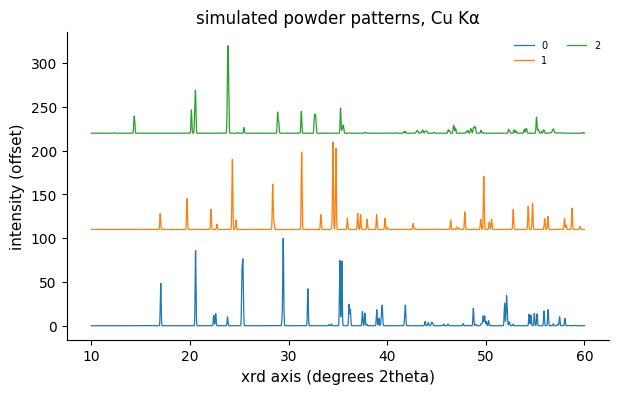

In [9]:
ax = mv.pl.spectra(md, "xrd", rows=[0, 1, 2], offset=110)
ax.set_title("simulated powder patterns, Cu Kα")

LiFePO₄ and NaFePO₄ are the same framework with a different alkali, and the
patterns show it: the same families of reflections, shifted.

## Identifying a phase

Feed one pattern back as though it had been measured, and ask which candidate it
is. This is phase identification against the library you already have.

In [10]:
measured = md.obsm["xrd_calc"][1]
mv.exp.match_xrd(md, measured, mv.grid_of(md, "xrd"))

md.obs[["name", "xrd_match", "xrd_match_rank"]].sort_values("xrd_match_rank")

,name,xrd_match,xrd_match_rank
1,NaFePO4,1.000000,1.0
2,Li3V2(PO4)3,0.062813,2.0
0,LiFePO4,0.046845,3.0


Row 1 comes back at 1.00 and the runner-up at 0.06, which is the margin you want
— NaFePO₄ and LiFePO₄ share a framework, so a scoring function that could not
tell them apart would be no use on the cases that matter.

```{warning}
`match_xrd` scores against the candidates in **this object** and nothing else,
and records that in `uns['xrd_match']['scored_against']`. A high score means
"the best of what you gave it", not "identified" — the true phase can be absent
from your library entirely.
```

## Choosing a calculator

Energies need a calculator, and which one is part of the result rather than an
implementation detail. `mv.calc.available()` reports what this installation can
run.

In [11]:
mv.calc.available()["emt"]

{'kind': 'classical',
 'method': 'EMT',
 'reference': None,
 'surrogate': True,
 'license': 'LGPL-2.1',
 'uncertainty': None,
 'note': 'ASE effective-medium theory. Parameterised only for Al Cu Ag Au Ni Pd Pt H C N O — enough to exercise a pipeline, not enough to screen with.'}

ASE's effective-medium theory is the only calculator matverse ships working. It
is parameterised for Al, Cu, Ag, Au, Ni, Pd, Pt, H, C, N and O — which excludes
the Fe, P and V in the cathodes above.

That is a real constraint, not a tutorial convenience, so the screen switches to
materials EMT can run. For anything else, register a machine-learned potential:

```python
from mace.calculators import mace_mp

mv.calc.register_calculator("mace-mpa", lambda: mace_mp(model="medium-mpa-0"),
                            kind="mlip", method="MACE-MPA-0",
                            reference="PBE+U", license="MIT")
```

In [12]:
metals = mv.datasets.metals()
metals.obs[["name", "lattice_parameter"]]

,name,lattice_parameter
0,Al,4.0495
1,Cu,3.6149
2,Ni,3.5240
3,Ag,4.0853
4,Au,4.0782
5,Pd,3.8907
6,Pt,3.9242


Published room-temperature lattice parameters for the seven face-centred cubic
metals. Relax them:

In [13]:
mv.pp.describe(metals)
mv.calc.relax(metals, level="emt", fmax=0.02)

metals.obs[["name", "energy_per_atom_emt", "relax_converged_emt"]]

,name,energy_per_atom_emt,relax_converged_emt
0,Al,-0.001562,True
1,Cu,-0.004953,True
2,Ni,-0.007592,True
3,Ag,0.000958,True
4,Au,0.002212,True
5,Pd,0.000420,True
6,Pt,-0.000106,True


In [14]:
mv.variants(metals)

['input', 'relaxed_emt']

The relaxed geometry becomes its own **variant** rather than replacing the
input, so "which structure was this energy computed on" stays answerable from
the object alone.

## Computing properties

Elastic constants by finite strain, phonons by frozen displacement, and thermal
conductivity from both.

In [15]:
mv.prop.elastic(metals, level="emt", source="relaxed_emt")
mv.prop.phonon(metals, level="emt", source="relaxed_emt", supercell=(1, 1, 1))
mv.prop.thermal_conductivity(metals, level="emt")

metals.obs[["name", "bulk_modulus_emt", "debye_temperature_emt",
            "thermal_conductivity_emt", "dynamically_stable_emt"]].round(1)

,name,bulk_modulus_emt,debye_temperature_emt,thermal_conductivity_emt,dynamically_stable_emt
0,Al,35.4,392.2,6.7,True
1,Cu,123.0,384.9,9.7,True
2,Ni,156.9,498.5,24.2,True
3,Ag,92.8,242.0,3.8,True
4,Au,159.2,162.1,1.1,True
5,Pd,171.4,282.4,4.3,True
6,Pt,275.8,222.5,2.9,True


Worth comparing against measured values rather than accepting:

| | EMT | experiment |
|---|---|---|
| bulk modulus, Cu | 123 | 140 GPa |
| bulk modulus, Ni | 157 | 180 GPa |
| bulk modulus, Al | 35 | 76 GPa |
| Debye temperature, Au | 162 | 165 K |
| Debye temperature, Ag | 242 | 225 K |
| Debye temperature, Al | 392 | 428 K |

Good for the transition metals EMT was fitted to, and a factor of two out on
aluminium's bulk modulus. That is the shape of the error a cheap potential
makes, and the reason a screen ranked on it is a shortlist rather than an
answer.

The conductivities look far too small next to the 400 W/m/K a copper wire is
sold on — but `mv.prop.thermal_conductivity` returns the **lattice**
contribution from the Slack model, and in a metal almost all the heat is carried
by electrons. A few W/m/K is the right magnitude for the phonons alone.

Every phonon mode is real, so all seven are dynamically stable, as elemental fcc
metals at their equilibrium lattice parameter should be. That check matters
because a composition can sit on the convex hull and still be a structure that
will not hold together.

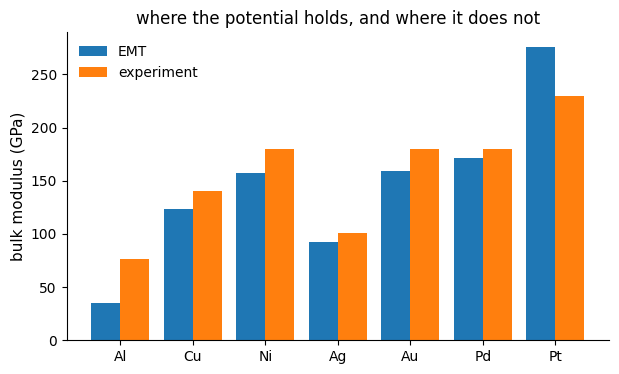

In [16]:
import matplotlib.pyplot as plt

measured = {"Al": 76, "Cu": 140, "Ni": 180, "Ag": 101, "Au": 180,
            "Pd": 180, "Pt": 230}
names = list(metals.obs["name"])
predicted = metals.obs["bulk_modulus_emt"].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(names))
ax.bar(x - 0.2, predicted, 0.4, label="EMT")
ax.bar(x + 0.2, [measured[n] for n in names], 0.4, label="experiment")
ax.set_xticks(x, names)
ax.set_ylabel("bulk modulus (GPa)")
ax.set_title("where the potential holds, and where it does not")
ax.legend()

Aluminium is the outlier and the rest track. A plot makes that visible in a way
the table above does not — EMT is not uniformly wrong, it is wrong about one
element, which is a different thing to know.

Text(0.5, 1.0, 'phonon density of states')

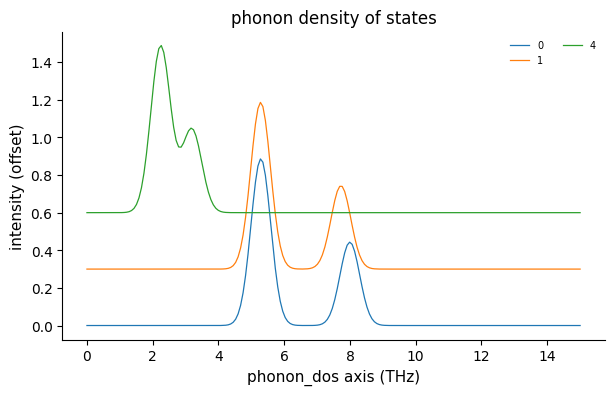

In [17]:
ax = mv.pl.spectra(metals, "phonon_dos", levels=("emt",), rows=[0, 1, 4],
                   offset=0.3)
ax.set_title("phonon density of states")

## Screening

`mv.screen.filter` takes criteria as `column__operator=value` and **deposits** a
boolean column plus the criteria that produced it, rather than returning a
shorter list — because which criterion a candidate failed is a result.

In [18]:
mv.screen.filter(metals,
                 thermal_conductivity_emt__gt=3.0,
                 bulk_modulus_emt__gt=50.0,
                 name="conductive_and_stiff")

metals.uns["screens"]["conductive_and_stiff"]

{'criteria': {'thermal_conductivity_emt__gt': 3.0,
  'bulk_modulus_emt__gt': 50.0},
 'n_pass': 4,
 'n_total': 7}

In [19]:
metals.obs[["name", "thermal_conductivity_emt", "bulk_modulus_emt",
            "conductive_and_stiff"]].round(1)

,name,thermal_conductivity_emt,bulk_modulus_emt,conductive_and_stiff
0,Al,6.7,35.4,False
1,Cu,9.7,123.0,True
2,Ni,24.2,156.9,True
3,Ag,3.8,92.8,True
4,Au,1.1,159.2,False
5,Pd,4.3,171.4,True
6,Pt,2.9,275.8,False


Subset when you actually want the short list — the object is an ordinary
AnnData, so `metals[metals.obs['conductive_and_stiff']]` works and carries
everything with it.

## Which chemistry passed?

The question that follows every screen. Because `X` is the composition matrix,
this is `rank_genes_groups` with the nouns changed.

In [20]:
mv.tl.rank_elements_groups(metals, "conductive_and_stiff")

metals.uns["rank_elements_groups"]["True"][
    ["element", "n_in_group", "frac_in_group", "odds_ratio", "pval"]]

,element,n_in_group,frac_in_group,odds_ratio,pval
0,Al,0,0.00,0.0,0.428571
1,Pt,0,0.00,0.0,0.428571
2,Au,0,0.00,0.0,0.428571
3,Ni,1,0.25,inf,1.000000
4,Cu,1,0.25,inf,1.000000
5,Pd,1,0.25,inf,1.000000
6,Ag,1,0.25,inf,1.000000


With seven elementals this is a formality. On a library of thousands it is the
operation that turns a pass/fail column into a statement about chemistry, and it
is the reason `X` holds composition rather than being left empty.

## What the object remembers

In [21]:
for step in mv.provenance(metals):
    print(step)

data.from_structures
pp.describe(source='input')
calc.relax(level='emt', source='input', fmax=0.02, key_added='relaxed_emt')
prop.elastic(level='emt', source='relaxed_emt', strain=0.01)
prop.phonon(level='emt', source='relaxed_emt', supercell=[1, 1, 1])
prop.thermal_conductivity(level='emt', temperature=300.0)
screen.filter(name='conductive_and_stiff', thermal_conductivity_emt__gt=3.0, bulk_modulus_emt__gt=50.0)
tl.rank_elements_groups(groupby='conductive_and_stiff', method='presence')


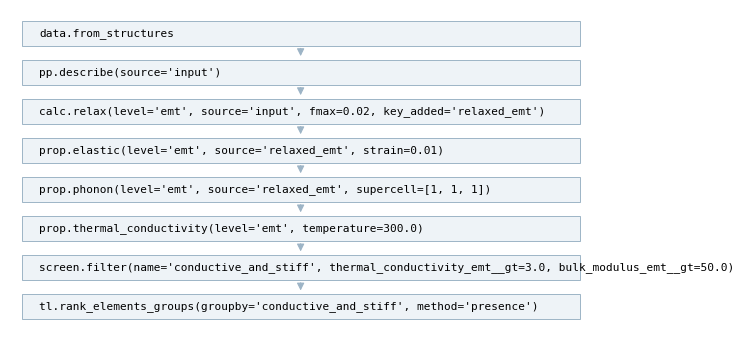

In [22]:
ax = mv.pl.provenance(metals)

Parameters are recorded with each call, so the history replays as code rather
than reading as a list of verbs. Saving keeps all of it:

```python
metals.write_h5ad("screen.h5ad")
```

Structures, descriptors, level records and provenance all survive, and the file
is an ordinary `h5ad` that anndata reads without matverse installed.

```{seealso}
[Screening, end to end](screening.ipynb) covers the same pipeline in more detail;
[Chemical space](chemical_space.ipynb) picks up where `rank_elements_groups` left
off; [Beyond one number](beyond_one_number.ipynb) covers curves, per-atom results
and measured data.
```